In [1]:
import xarray as xr
import rioxarray
from pathlib import Path
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import lightgbm as lgb 
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.ndimage import median_filter, minimum_filter, maximum_filter, uniform_filter
from tqdm import tqdm

In [2]:
ds = xr.open_zarr("../data/silver/ghana-2022.zarr", mask_and_scale=False, consolidated=False)
print(ds)

<xarray.Dataset> Size: 56GB
Dimensions:               (y: 73757, x: 50398)
Coordinates:
  * y                     (y) float64 590kB 11.17 11.17 11.17 ... 4.539 4.539
  * x                     (x) float64 403kB -3.261 -3.261 -3.261 ... 1.273 1.273
Data variables: (12/15)
    green                 (y, x) uint8 4GB dask.array<chunksize=(1000, 1000), meta=np.ndarray>
    swir22                (y, x) uint8 4GB dask.array<chunksize=(1000, 1000), meta=np.ndarray>
    cloud_confidence      (y, x) uint8 4GB dask.array<chunksize=(1000, 1000), meta=np.ndarray>
    blue                  (y, x) uint8 4GB dask.array<chunksize=(1000, 1000), meta=np.ndarray>
    B07                   (y, x) uint8 4GB dask.array<chunksize=(1000, 1000), meta=np.ndarray>
    scene_classification  (y, x) uint8 4GB dask.array<chunksize=(1000, 1000), meta=np.ndarray>
    ...                    ...
    B8A                   (y, x) uint8 4GB dask.array<chunksize=(1000, 1000), meta=np.ndarray>
    B06                   (y, x) 

None


KeyboardInterrupt: 

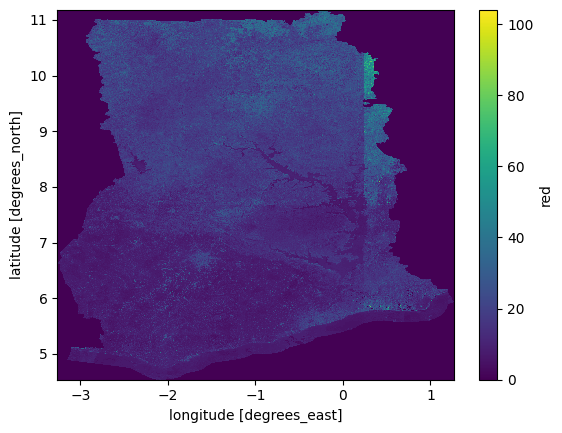

<Figure size 1500x200 with 0 Axes>

In [3]:
# Check CRS and resolution
print(ds.rio.crs)

# Downsample & plot
step = 100
red_small_ds = ds.red.isel(y=slice(None, None, step), x=slice(None, None, step))
red_small_ds.plot()

plt.figure(figsize=(15,2))
sns.histplot(red_small_ds.values.ravel(), binwidth=5)

# Generate chunks

In [4]:
import shutil

chunks_folderpath = Path("../data/silver/ghana-2022-chunks")
if chunks_folderpath.exists():
    shutil.rmtree(chunks_folderpath)
    
chunks_folderpath.mkdir(exist_ok=True)

In [ ]:
import numpy as np
import pandas as pd
import gc
from pathlib import Path
from tqdm import tqdm

# Define your columns and variables
band_names = ["red", "green", "blue", "rededge", "B06", "B07", "nir", "B8A", "swir11", "swir22"]
aux_names = ["cloud_confidence", "scene_classification", "valid_observations"]
grid_vars = band_names + ["cloud_confidence"]
cols = band_names + aux_names + ["ethz_map"]

chunk_size = 500
n_chunks = (ds.sizes["y"] + chunk_size - 1) // chunk_size

# Pre-compute the neighborhood offset grids for 3x3, 5x5, and 11x11 windows
# This allows us to pull 11x11 patches instantly using NumPy broadcasting
sizes = [3, 5, 11]
offsets = {}
for s in sizes:
    d = np.arange(-(s // 2), (s // 2) + 1)
    dy, dx = np.meshgrid(d, d, indexing='ij')
    offsets[s] = (dy.ravel(), dx.ravel())

for i in tqdm(range(0, ds.sizes["y"], chunk_size), total=n_chunks, desc="Processing chunks"):
    
    PX_BUFFER = 5
    start_y = max(0, i - PX_BUFFER)
    end_y = min(ds.sizes["y"], i + chunk_size + PX_BUFFER)
    chunk_ds = ds[cols].isel(y=slice(start_y, end_y))
    
    valid_start = 0 if i == 0 else PX_BUFFER
    valid_end = chunk_ds.sizes['y'] - PX_BUFFER
    if i + chunk_size >= ds.sizes["y"]:
        valid_end = chunk_ds.sizes['y']
        
    # Generate x,y coords we will consider
    y_grid = np.arange(valid_start, valid_end, 100) 
    x_grid = np.arange(0, chunk_ds.sizes["x"], 100)
    
    Y_pts, X_pts = np.meshgrid(y_grid, x_grid, indexing='ij')
    y_pts = Y_pts.ravel()
    x_pts = X_pts.ravel()

    # Figure out whether we'll keep each x,y
    keep_mask = np.ones(len(y_pts), dtype=bool)

    # Drop any (x,y) where all bands are 0
    all_bands_zero = np.ones(len(y_pts), dtype=bool)
    for band in band_names:
        band_vals = chunk_ds[band].values[y_pts, x_pts]
        all_bands_zero &= (band_vals == 0)
    keep_mask &= ~all_bands_zero

    # Drop any (x,y) with no ETHZ prediction
    ethz_vals = chunk_ds["ethz_map"].values[y_pts, x_pts]
    keep_mask &= ~pd.isna(ethz_vals)

    # Only keep valid (x,y) coords
    valid_y_pts = y_pts[keep_mask]
    valid_x_pts = x_pts[keep_mask]

    # Initialize dictionary with the true lat/lon for our valid points
    chunk_data = {"lon": chunk_ds.x.values[valid_x_pts], "lat": chunk_ds.y.values[valid_y_pts]}
    
    if len(valid_y_pts) == 0:
        continue
    
    # -------------------------------------------------------------------
    # STEP 3: WINDOW EXTRACTION AND FAST MATH
    # -------------------------------------------------------------------
    for col in cols:
        arr = chunk_ds[col].values 
        
        # Store the original center pixel
        chunk_data[col] = arr[valid_y_pts, valid_x_pts]
        
        if col in grid_vars:
            for s in sizes:
                dy, dx = offsets[s]
                
                # Broadcast center points + offsets to get coordinates for all windows at once
                win_y = valid_y_pts[:, None] + dy
                win_x = valid_x_pts[:, None] + dx
                
                # Clip to array boundaries to prevent errors on the absolute edges of the map
                win_y = np.clip(win_y, 0, arr.shape[0] - 1)
                win_x = np.clip(win_x, 0, arr.shape[1] - 1)
                
                # Extract the windows! Shape becomes (N_valid_points, s*s)
                # We cast to float32 only for the extracted patches, saving massive RAM
                windows = arr[win_y, win_x].astype(np.float32)
                
                suffix = f"{s}x{s}"
                # Compute math directly across the window axis (axis=1)
                chunk_data[f"{col}_{suffix}_median"] = np.median(windows, axis=1).astype(arr.dtype)
                chunk_data[f"{col}_{suffix}_min"] = np.min(windows, axis=1).astype(arr.dtype)
                chunk_data[f"{col}_{suffix}_max"] = np.max(windows, axis=1).astype(arr.dtype)
                chunk_data[f"{col}_{suffix}_var"] = np.var(windows, axis=1).astype(arr.dtype)

        del arr

    # Dump directly to Parquet and wipe the dictionary
    df_chunk = pd.DataFrame(chunk_data)
    df_chunk.to_parquet(chunks_folderpath / f"chunk_{i:05d}.parquet")
    del chunk_data, df_chunk, chunk_ds
    gc.collect()

print("Processing complete!")

Processing chunks:   0%|                                                                                                                                      | 0/148 [00:00<?, ?it/s]